In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [104]:
df = pd.read_csv('Data/data.csv', encoding='latin1')
print(df.head())

  Company_Name Dependent-Company Status year of founding  \
0     Company1                  Success          No Info   
1     Company2                  Success             2011   
2     Company3                  Success             2011   
3     Company4                  Success             2009   
4     Company5                  Success             2010   

  Age of company in years  Internet Activity Score  \
0                 No Info                     -1.0   
1                       3                    125.0   
2                       3                    455.0   
3                       5                    -99.0   
4                       4                    496.0   

     Short Description of company profile  \
0                      Video distribution   
1                                     NaN   
2                Event Data Analytics API   
3  The most advanced analytics for mobile   
4   The Location-Based Marketing Platform   

                              Industry of c

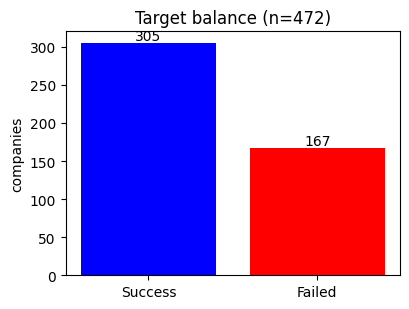

success rate: 0.646


In [105]:
counts = df["Dependent-Company Status"].dropna().value_counts()
fig, ax = plt.subplots(figsize=(4.2, 3.2))
bars = ax.bar(counts.index, counts.values, color=["blue", "red"])
ax.bar_label(bars)
ax.set_ylabel("companies"); ax.set_title(f"Target balance (n={len(df)})")
plt.tight_layout(); plt.show()
print("success rate:", round((df["Dependent-Company Status"] == "Success").mean(), 3))


In [156]:
X = df.drop(columns=["Dependent-Company Status"])
y = df["Dependent-Company Status"]

# As data is imbalanced, we will use stratified sampling to ensure that the train and test sets have the same proportion of classes as the original dataset.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [157]:
numeric_cols = X_train.select_dtypes(include=np.number).columns
print("Numeric columns:", numeric_cols)


Numeric columns: Index(['Internet Activity Score', 'Employee Count',
       'Employees count MoM change', 'Last Funding Amount',
       'Number of Co-founders', 'Number of of advisors',
       'Team size Senior leadership', 'Industry trend in investing'],
      dtype='object')


In [158]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 377 entries, 375 to 119
Columns: 114 entries, Company_Name to Renown score
dtypes: float64(5), int64(3), object(106)
memory usage: 338.7+ KB


In [159]:
nan_counts = X_train.isna().sum()
print(nan_counts[nan_counts > 0])

Age of company in years                                                                                                  35
Internet Activity Score                                                                                                  51
Short Description of company profile                                                                                    113
Industry of company                                                                                                      99
Focus functions of company                                                                                               22
Investors                                                                                                               106
Employee Count                                                                                                          127
Employees count MoM change                                                                                              154
Has the 

In [160]:
print(X_train.dtypes.value_counts())

object     106
float64      5
int64        3
Name: count, dtype: int64


In [161]:
def shorten(c, n=38):
    """Compact a long column name for plot labels."""
    c = c.replace("Survival through recession, based on existence of the company through recession times",
                  "recession_survival")
    c = (c.replace("Number of ", "n_").replace("Percent_skill_", "skill_")
          .replace(" organizations", "").replace("for Founders and Co-founders", "(founders)"))
    return c if len(c) <= n else c[:n - 3] + "..."

columns with >30% missing: 13 of 114  |  >50%: 5


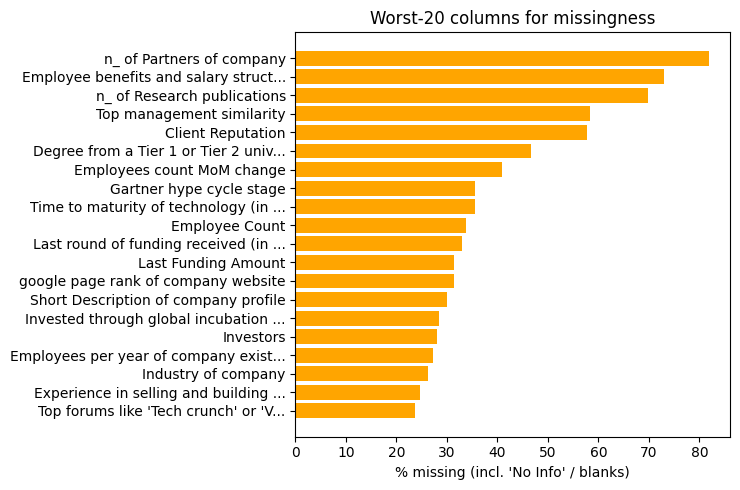

In [162]:
MISS_TOKENS = {"no info", "", "nan", "na", "n/a", "none", "unknown amount"}


def missing_mask(col):
    s = X_train[col].astype(str).str.strip().str.lower()
    return X_train[col].isna() | s.isin(MISS_TOKENS)


missrate = pd.Series({c: missing_mask(c).mean() for c in X_train}).sort_values(ascending=False)
print(f"columns with >30% missing: {(missrate > 0.30).sum()} of {X_train.shape[1]}  |  >50%: {(missrate > 0.50).sum()}")

top = missrate.head(20)
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.barh([shorten(c) for c in top.index][::-1], (top.values * 100)[::-1], color='ORANGE')
ax.set_xlabel("% missing (incl. 'No Info' / blanks)"); ax.set_title("Worst-20 columns for missingness")
plt.tight_layout(); plt.show()

In [163]:
# Remove columns with 30% or more missing values
columns_to_remove = missrate[missrate >= 0.30].index

raw = X_train.drop(columns=columns_to_remove)

print(f"Removed {len(columns_to_remove)} columns")
print("Remaining columns:", raw.shape[1])

Removed 13 columns
Remaining columns: 101


In [164]:
print(raw.dtypes.value_counts())

object     96
int64       3
float64     2
Name: count, dtype: int64


In [165]:
DROP_SUBSTR = ["Company_Name", "Short Description", "Investors", "Founding Date", "Funding Date",
               "Specialization of highest", "Industry of company", "Focus functions"]
ORD_MAPS = [
    {"low": 0, "medium": 1, "high": 2},
    {"small": 0, "medium": 1, "large": 2},
    {"bachelors": 0, "masters": 1, "phd": 2},
    {"nothing": 0, "low": 1, "medium": 2, "high": 3},
    {"0 to 2": 0, "2 to 5": 1, "5 to 10": 2, "10 to 15": 3, "15 to 20": 4},
]


def _norm(s):
    return s.astype(str).str.strip().str.lower()


def clean(df):
    df = df.copy()
    df = df.drop(columns=[c for c in df.columns
                          if any(k.lower() in c.lower() for k in DROP_SUBSTR)])
    for c in df.columns:                                  # missing tokens -> NaN
        df[c] = df[c].astype(str).str.strip().mask(_norm(df[c]).isin(MISS_TOKENS) | df[c].isna())
    miss = df.isna().mean()
    df = df.drop(columns=[c for c in df.columns if miss[c] > 0.55 and "recession" not in c.lower()])

    kinds = {}
    for c in list(df.columns):
        nn = df[c].dropna()
        vals = set(_norm(nn.to_frame()[c]))
        if len(nn) and nn.astype(str).str.strip().str.match(r"^-?\d+(\.\d+)?$").mean() > 0.85:
            df[c] = pd.to_numeric(df[c].astype(str).str.strip(), errors="coerce"); kinds[c] = "num"
        elif vals <= {"yes", "no"}:
            df[c] = _norm(df[c]).map({"yes": 1, "no": 0}); kinds[c] = "bin"
        elif (m := next((m for m in ORD_MAPS if vals <= set(m)), None)) is not None:
            df[c] = _norm(df[c]).map(m); kinds[c] = "ord"
        elif nn.nunique() <= 12:
            kinds[c] = "nom"
        else:
            df = df.drop(columns=[c])
    nom = [c for c, k in kinds.items() if k == "nom" and c in df.columns]
    df = pd.get_dummies(df, columns=nom, dummy_na=False, dtype=float)
    return df, kinds      # NaNs are left in on purpose - see section 9


X, kinds = clean(X_train)
y = (y_train.str.strip().str.lower() == "success").astype(int)

print("clean feature matrix:", X.shape, "| success rate:", round(y.mean(), 3))
print("column kinds:", pd.Series(kinds).value_counts().to_dict())
print("NaNs still to impute:", int(X.isna().sum().sum()),
      f"({X.isna().mean().mean():.1%} of all cells) - imputed after the split")
print("\nNote: 472 rows but ~130 features (after one-hot). This is a small-n, high-p regime -")
print("importances will be noisy; we lean on error bars and read rankings, not exact values.")

clean feature matrix: (377, 127) | success rate: 0.647
column kinds: {'num': 39, 'bin': 35, 'ord': 12, 'nom': 11}
NaNs still to impute: 4294 (9.0% of all cells) - imputed after the split

Note: 472 rows but ~130 features (after one-hot). This is a small-n, high-p regime -
importances will be noisy; we lean on error bars and read rankings, not exact values.


In [166]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import roc_auc_score

In [167]:
def _norm(s):
    return s.astype("string").str.strip().str.lower()

In [168]:
X_test_cl, kinds = clean(X_train)
y_test_cl = (y_train.str.strip().str.lower() == "success").astype(int)

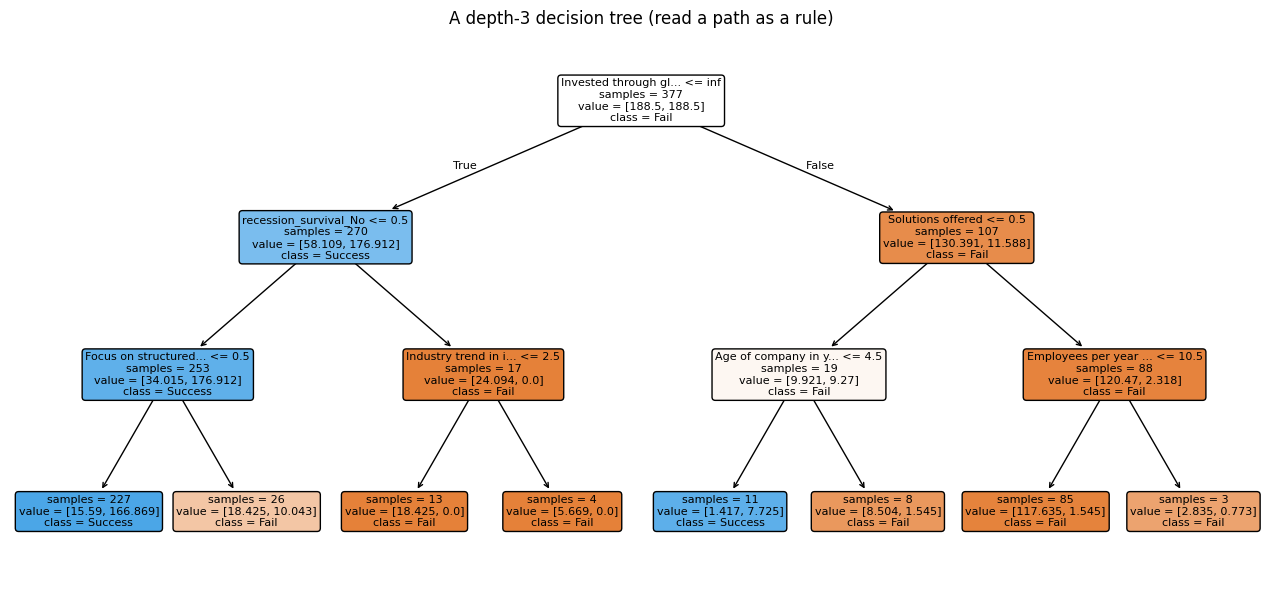

tree test AUC: 0.947


In [126]:
tree = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight="balanced").fit(X, y)
fig, ax = plt.subplots(figsize=(13, 6))
plot_tree(tree, feature_names=[shorten(c, 22) for c in X.columns], class_names=["Fail", "Success"],
          filled=True, rounded=True, impurity=False, fontsize=8, ax=ax)
ax.set_title("A depth-3 decision tree (read a path as a rule)")
plt.tight_layout(); plt.show()
print("tree test AUC:", round(roc_auc_score(y_test_cl, tree.predict_proba(X_test_cl)[:, 1]), 3))

In [129]:
lk = "Survival through recession, based on existence of the company through recession times"
ct = pd.crosstab(df[lk].astype(str).str.strip(), df["Dependent-Company Status"])
print(ct)
print("\n'No' (did not survive the recession) => 31 Failed, 0 Success: a perfect predictor of failure.")
print("This can only be known AFTER the outcome. It is leakage, not a driver.")

Dependent-Company Status                            Failed  Success
Survival through recession, based on existence ...                 
No                                                      31        0
No Info                                                 91        7
Not Applicable                                          35      233
Yes                                                     10       65

'No' (did not survive the recession) => 31 Failed, 0 Success: a perfect predictor of failure.
This can only be known AFTER the outcome. It is leakage, not a driver.


In [134]:
X_dlk = X.drop(columns=[lk], errors="ignore")
X_test_dlk = X_test_cl.drop(columns=[lk], errors="ignore")

In [144]:
columns_to_remove = [
    "Country of company",
    "Investors",
    "Survival through recession, based on existence of the company through recession times"
]

encoded_cols = []

for col in columns_to_remove:
    encoded_cols.extend([
        c for c in X.columns
        if c.startswith(col + "_")
    ])

X_dlk = X_test_cl.drop(columns=encoded_cols)
X_test_dlk = X_test_cl.drop(columns=encoded_cols)

In [145]:
tree = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight="balanced").fit(X_dlk, y)
print("tree test AUC:", round(roc_auc_score(y_test_cl, tree.predict_proba(X_test_dlk)[:, 1]), 3))

tree test AUC: 0.961


In [146]:
print("Original:", lk in df.columns)
print("X_dlk:", lk in X_dlk.columns)
print("X_test_dlk:", lk in X_test_dlk.columns)

print([
    c for c in X_dlk.columns
    if "recession" in c.lower()
])

Original: True
X_dlk: False
X_test_dlk: False
[]


In [140]:
from sklearn.metrics import accuracy_score

y_pred = tree.predict(X_test_cl)

accuracy = accuracy_score(y_test_cl, y_pred)

print("Test accuracy:", round(accuracy, 3))

Test accuracy: 0.92


In [143]:
from sklearn.metrics import accuracy_score

y_pred = tree.predict(X_test_dlk)

accuracy = accuracy_score(y_pred, y)

print("Test accuracy:", round(accuracy, 3))

Test accuracy: 0.92


In [148]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import roc_auc_score, classification_report, brier_score_loss
from sklearn.calibration import calibration_curve
import re


In [155]:
df = df.drop(columns=[lk], errors="ignore")

In [ ]:
	
logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, class_weight="balanced"))
logreg.fit(X_dlk, y)
lr_auc = roc_auc_score(y_test_cl, logreg.predict_proba(X_test_cl)[:, 1])
coef = pd.Series(logreg[-1].coef_[0], index=X.columns)
odds = np.exp(coef)
top = pd.concat([coef.sort_values().head(8), coef.sort_values().tail(8)])
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.barh([shorten(c) for c in top.index], top.values,
        color=["BLUE" if v > 0 else "RED" for v in top.values])
ax.axvline(0, color="0.3", lw=1); ax.set_xlabel("standardised logistic coefficient")
ax.set_title(f"Logistic regression - strongest +/- features (test AUC={lr_auc:.3f})")
plt.tight_layout(); plt.show()
print("Read as odds ratios, e.g. top positive feature:",
      shorten(coef.idxmax()), "-> OR =", round(odds.max(), 2))

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values